In [1]:
# MPI

import os
import sys

# Add the '../sources' directory to the Python path using source_dir,
# and add its parent directory as well.
source_dir = os.path.abspath(os.path.join("..", "sources"))
parent_dir = os.path.abspath(os.path.join(source_dir, os.pardir))

for directory in [source_dir, parent_dir]:
    if directory not in sys.path:
        sys.path.insert(0, directory)


print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal, ScriptParam, ScriptParamVector3
from sources.mpb_configurator import MPBSchemeConfigurator  
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *


n_InP = 3.1

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "test_field_analysis"


## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice
lattice_2D = Lattice(type="TXY")
lattice_slab = Lattice(type="TXY", size=mp.Vector3(1, 1, height_supercell))
centers = lattice_2D.get_centers()
k_points = lattice_2D.get_high_symmetry_k_points()



bulk_2D = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": InP})
bulk_slab = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": slab_block_size, "material": InP})
hole1_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": 1e20, "material": air})
hole2_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": 1e20, "material": air})
hole1_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": height_slab, "material": air})
hole2_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": height_slab, "material": air})

photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=[bulk_2D, hole1_2D, hole2_2D])
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=[bulk_slab, hole1_slab, hole2_slab])

## Define the simulation

configuration_options = dict(
    resolution = 32, 
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=20, 
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-efield-phase output-efield output-hfield)",
)



mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven", "zodd"], **configuration_options)
script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)

from sources.mpi_differential_evolution import MPIDiffEvoSimulation
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer

# Create your Simulation instance.
simulation_2D = Simulation(simulation_name=name+"_2D",
                 script=script_2D,
                 log_level = Simulation.WARNING)

simulation_slab = Simulation(simulation_name=name+"_slab",
                    script=script_slab,
                    log_level = Simulation.WARNING)
simulation_2D.run_hpc(mpb_command_line_params={"r1":0.10, "r2":0.339})


Included '/zhome/2f/7/202918/phc_nzi/sources' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.
Epsilon of InP:  9.61
Found script param: size with value: (vector3 1e+20 1e+20 h)
Found script param: radius with value: r1
Found script param: radius with value: r2
Found script param: radius with value: r1
Found script param: height with value: h
Found script param: radius with value: r2
Found script param: height with value: h
COMMANDS ['(define-param r1 0.3)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.4)', '(define-param r1 0.3)', '(define-param r2 0.2)']


In [2]:
# MPI
import matplotlib.pyplot as plt
import os
import sys

# Add the '../sources' directory to the Python path using source_dir,
# and add its parent directory as well.
source_dir = os.path.abspath(os.path.join("..", "sources"))
parent_dir = os.path.abspath(os.path.join(source_dir, os.pardir))

for directory in [source_dir, parent_dir]:
    if directory not in sys.path:
        sys.path.insert(0, directory)


print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal, ScriptParam, ScriptParamVector3
from sources.mpb_configurator import MPBSchemeConfigurator  
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *



n_InP = 3.1

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
mat = Material(epsilon = 20)
## Simulation Name: 
name = "slab_field_analysis"


## Define the geometry
radius = ScriptParam("r", 0.35)
height_slab = 0.4
height_supercell = 3

## Define the lattice
lattice = Lattice(type="TX", size=mp.Vector3(1, 1, height_supercell))
print(lattice._mp_lattice.basis)
k_point_1_cartesian = mp.Vector3(0,0,0)
k_point_2_cartesian = mp.Vector3(0.05,0,0)
k_point_1_reciprocal = lattice.cartesian_to_reciprocal(k_point_1_cartesian)
k_point_2_reciprocal = lattice.cartesian_to_reciprocal(k_point_2_cartesian)
k_points = {"k_points_values": [k_point_1_reciprocal, k_point_2_reciprocal],
            "k_points_labels": ["G", "$K_X$"]}
print(k_points)


center = mp.Vector3(0,0,0)




bulk= Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, height_slab), "material": mat})
hole= Geometry(geom_type=mp.Cylinder, params={"center": center, "radius": radius, "height": height_slab, "material": air})


photonic_crystal = PhotonicCrystal(lattice=lattice, atoms=[bulk, hole])


## Define the simulation

configuration_options = dict(
    resolution = 32, 
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=5,
    #extra_runner_command = "(output-at-kpoint (list-ref k-points 1) fix-efield-phase output-nonbloch-efield-z output-nonbloch-hfield-y)",
    extra_runner_command = "fix-efield-phase output-nonbloch-efield-z output-nonbloch-hfield-y",   
)



mpb_configuration = MPBSchemeConfigurator(photonic_crystal, ["zeven", "zodd"], **configuration_options)
script = mpb_configuration.get_scheme_config(join_newline=True)

from sources.mpi_differential_evolution import MPIDiffEvoSimulation
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer

# Create your Simulation instance.
simulation = Simulation(simulation_name=name+"",
                 script=script,
                 log_level = Simulation.WARNING)

#simulation.run_hpc_lsf(mpb_command_line_params={"r":0.35}, num_procs=25)

Included '/zhome/2f/7/202918/phc_nzi/sources' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.
Epsilon of InP:  9.61
<<1.0 0.5000000000000001 0.0>
 <0.0 0.8660254037844388 0.0>
 <0.0 0.0 1.0>>
{'k_points_values': [Vector3<0.0, 0.0, 0.0>, Vector3<0.05, 0.02500000000000001, 0.0>], 'k_points_labels': ['G', '$K_X$']}
Found script param: radius with value: r
COMMANDS ['(define-param r 0.35)']


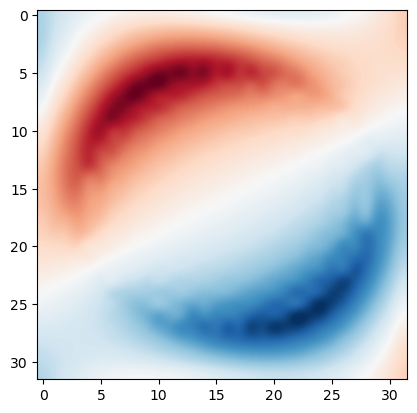

In [3]:
field, description = simulation.load_and_convert_field_data(2, 2, "z", "zodd", "e", conversion_options={"rectify": True}, file_comp="z")
plt.imshow(field.real[..., field.shape[2]//2], cmap='RdBu', interpolation='spline36')


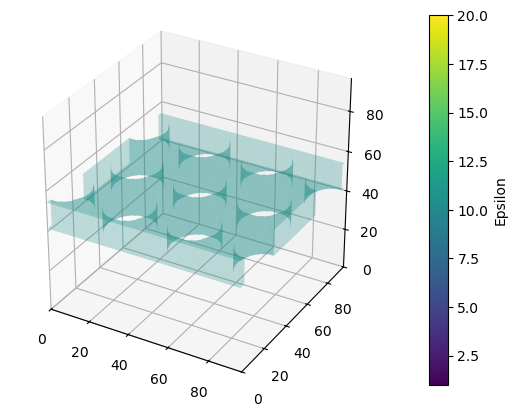

In [6]:

vwr = SimulationViewer(simulation)
conversion_options = {"rectify": True, "periods" : (3,3,1)}
vwr.plot_epsilon_3d(conversion_options=conversion_options)

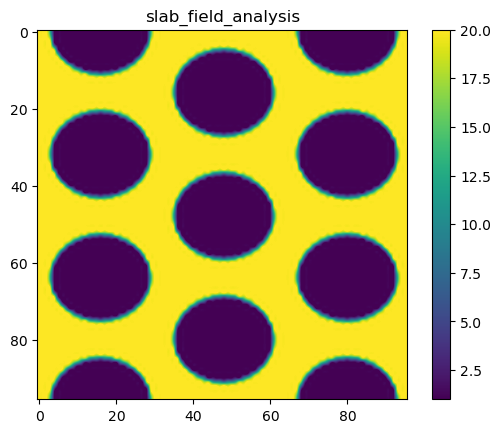

Vector3<0.23, 0.0, 0.0>
k index        7.000000
k1             0.050000
k2             0.025000
k3             0.000000
kmag/2pi       0.050000
zodd band 1    0.047218
zodd band 2    0.297148
zodd band 3    0.297929
zodd band 4    0.400156
zodd band 5    0.411249
zodd band 6    0.413053
zodd band 7    0.432921
zodd band 8    0.433256
Name: 6, dtype: float64


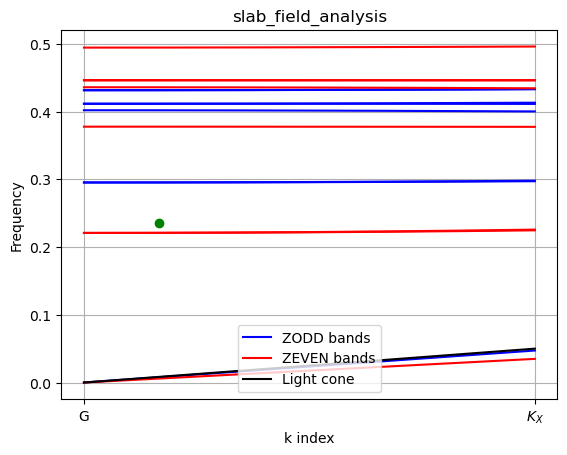

In [8]:

vwr = SimulationViewer(simulation)
vwr.newfig()
vwr.simulation.load_epsilon()
vwr.plot_epsilon_2d()
vwr.show()
vwr.plot_band_diagram("zodd", k_points_path=k_points, colors="blue")
vwr.plot_band_diagram("zeven", k_points_path=k_points, colors="red")
df = simulation.load_frequency_data("zodd")
target_cartesian = mp.Vector3(0.23, 0)
target_reciprocal = lattice.cartesian_to_reciprocal(target_cartesian)
target_reciprocal = target_cartesian
print(target_reciprocal)
k = simulation.find_closest_k_point_row(df, target_reciprocal)
print(k)

vwr.plot_light_cone(df)
plt.plot(2, 0.236, "go")
vwr.show()


In [9]:
display(df)

,k index,k1,k2,k3,kmag/2pi,zodd band 1,zodd band 2,zodd band 3,zodd band 4,zodd band 5,zodd band 6,zodd band 7,zodd band 8
0,1,0.000000,0.000000,0,0.000000,0.000000,0.295241,0.295311,0.401916,0.411342,0.411658,0.431434,0.431494
1,2,0.008333,0.004167,0,0.008333,0.007877,0.295300,0.295379,0.401859,0.411378,0.411665,0.431481,0.431538
2,3,0.016667,0.008333,0,0.016667,0.015753,0.295468,0.295592,0.401691,0.411448,0.411724,0.431616,0.431674
3,4,0.025000,0.012500,0,0.025000,0.023626,0.295735,0.295957,0.401423,0.411459,0.411916,0.431827,0.431914
4,5,0.033333,0.016667,0,0.033333,0.031495,0.296104,0.296471,0.401068,0.411416,0.412225,0.432113,0.432260
5,6,0.041667,0.020833,0,0.041667,0.039360,0.296575,0.297129,0.400641,0.411343,0.412611,0.432477,0.432708
6,7,0.050000,0.025000,0,0.050000,0.047218,0.297148,0.297929,0.400156,0.411249,0.413053,0.432921,0.433256


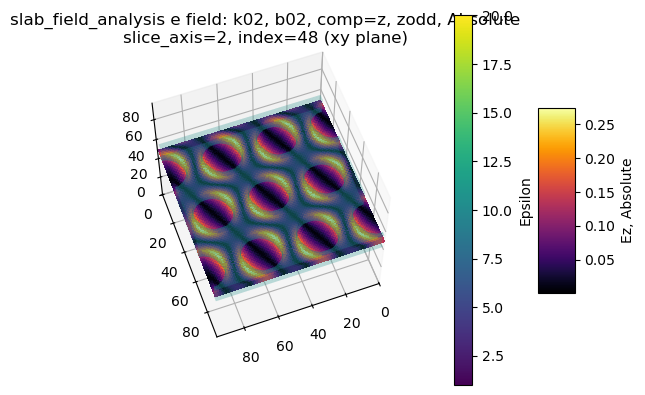

In [15]:


conversion_options = {
    "periods": (3,3,1),
    "phase": 0,
    "rectify":  True,
    
}
# vwr.newfig()
# vwr.plot_field_data(42,2,"x", "tm", "e", overlay_epsilon=True, conversion_options=conversion_options, plot_mode="real", nonbloch = True) 
# vwr.show()

# vwr.newfig()
# vwr.plot_field_data(42,2,"y", "tm", "e", overlay_epsilon=True, conversion_options=conversion_options, plot_mode="real", nonbloch = True) 
# vwr.show()

vwr.newfig()
vwr.plot_field_data(2,2,"z", "zodd", "e", overlay_epsilon=True, conversion_options=conversion_options, plot_mode="abs", nonbloch = True, cmap="inferno", file_comp = "z",slice_axis = 2) 
vwr.rotate_fig(70,60)
vwr.show()

In [16]:
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer
import pandas as pd
import matplotlib.pyplot as plt



class FieldAnalyzer:
    def __init__(self,simulation: Simulation,  bands, polarization):
        self.bands = bands
        self.polarization = polarization
        self.simulation = simulation 
        self.df = self.simulation.load_frequency_data(self.polarization)  
        self.result_df = None 

    def load_field_data(self, k_index, band_index, field_type, nonbloch = True, comp = "z", periods = 3):
        field =  self.simulation.load_and_convert_field_data(k_index, band_index, comp, self.polarization, field_type, 
                                                           nonbloch = nonbloch, conversion_options= {"periods": periods, "rectify":  True}, 
                                                           file_comp=comp)[0]  
        return self.make_2D(field)
    
    def load_hfield_data(self, k_index, band_index, comp, periods = 3, nonbloch = True) :
        return self.load_field_data(k_index, band_index, "h", nonbloch, comp, periods)
    
    def load_efield_data(self, k_index, band_index, comp, periods = 3, nonbloch = True) :
        return self.load_field_data(k_index, band_index, "e", nonbloch, comp , periods)
    
    def make_2D(self, field_data):
        if field_data.ndim == 2:
            return field_data
        elif field_data.ndim == 3:
            return field_data[:,:,field_data.shape[2]//2]
        
    def field_less_than_zero(self, field_data):
        """Returns a boolean mask for values less than zero"""
        return field_data < 0
    
    def field_greater_than_zero(self, field_data):
        """Returns a boolean mask for values greater than zero or equal to zero"""
        return field_data >= 0
    
    
    def get_mask(self, field_data, mask_func):
        return mask_func(field_data)
    
    def mask_field_data(self, field_data, mask):
        """Mask field data by setting values where mask is False to None/np.nan
        while preserving the shape of the array"""
        masked = field_data.copy()
        masked[~mask] = 0
        return masked

    def average_2D(self, field_data):
        if field_data.ndim == 3:
            raise ValueError("Field data must be 2D")
        shape = field_data.shape
        return field_data.sum() / (shape[0] * shape[1])
    
    def average_1D(self, field_data, axis):
        if field_data.ndim == 3:
            raise ValueError("Field data must be 2D")
        if axis not in [0, 1]:
            raise ValueError("Axis must be 0 or 1")
        if axis == 0:
            return field_data[0,:].sum() / field_data.shape[1]
        elif axis == 1:
            return field_data[:,0].sum() / field_data.shape[0]
        
    def get_kmag_freq(self, k_idx, b_idx):
        kmag, freq = self.simulation.get_kmag_freq(self.df, k_idx, self.polarization, b_idx)
        return kmag, freq
    
    def get_freq(self, k_idx, b_idx):
        return self.simulation.get_freq(self.df, k_idx, self.polarization, b_idx)
    
    def get_eps_mu(self, k_index, band_index, component_i, component_j, average_type = "2D", nonbloch = True, periods = 3):
        e_field_i = self.load_efield_data(k_index, band_index, component_i, periods = periods, nonbloch = nonbloch)
        h_field_j = self.load_hfield_data(k_index, band_index, component_j, periods = periods, nonbloch = nonbloch)
        

        mask_I = self.get_mask(h_field_j.real, self.field_greater_than_zero)
        mask_II = self.get_mask(h_field_j.real, self.field_less_than_zero)

        # Create the masked complex fields for both regions
        e_field_i_masked_I = self.mask_field_data(e_field_i, mask_I)
        e_field_i_masked_II = self.mask_field_data(e_field_i, mask_II)
        h_field_j_masked_I = self.mask_field_data(h_field_j, mask_I)
        h_field_j_masked_II = self.mask_field_data(h_field_j, mask_II)

        
        if average_type == "2D":
            e_field_i_masked_I_avg = self.average_2D(e_field_i_masked_I)
            e_field_i_masked_II_avg = self.average_2D(e_field_i_masked_II)
            h_field_j_masked_I_avg = self.average_2D(h_field_j_masked_I)
            h_field_j_masked_II_avg = self.average_2D(h_field_j_masked_II)

        elif average_type == "1D":
            e_field_i_masked_I_avg = self.average_1D(e_field_i_masked_I, 0)
            e_field_i_masked_II_avg = self.average_1D(e_field_i_masked_II, 0)
            h_field_j_masked_I_avg = self.average_1D(h_field_j_masked_I, 0)
            h_field_j_masked_II_avg = self.average_1D(h_field_j_masked_II, 0)

            
        e_over_h_I = e_field_i_masked_I_avg.real / h_field_j_masked_I_avg.real
        e_over_h_II = e_field_i_masked_II_avg.real / h_field_j_masked_II_avg.real

        mu_I = e_over_h_I
        mu_II = e_over_h_II
        eps_I = 1/e_over_h_I
        eps_II = 1/e_over_h_II

        k_mag, freq = self.get_kmag_freq(k_index, band_index)
        k_mag_over_freq = k_mag / freq
        mu_I = mu_I * k_mag_over_freq
        mu= np.emath.sqrt(mu_I)*np.emath.sqrt(mu_II)
        eps = np.emath.sqrt(eps_I)*np.emath.sqrt(eps_II)

        eps = eps*k_mag_over_freq
        mu = mu*k_mag_over_freq

        return  eps, mu
    
    def get_impedance(self, eps, mu):        
        return np.emath.sqrt(eps/mu)
    
    def get_refractive_index(self, eps, mu):
        return np.emath.sqrt(eps)*np.emath.sqrt(mu)
    
    def get_k_indices(self):
        return self.simulation.get_kpoints_indices(self.df)
    
    def get_eps_mu_impedance_neff(self, component_i, component_j , average_type = "2D", nonbloch = True, periods = 3, plot = False):
        k_indices = self.get_k_indices()
        bands_freqs = []
        for band in self.bands:
            freqs = []
            for k_idx in k_indices:
                freq = self.get_freq(k_idx, band)
                freqs.append(freq)
            bands_freqs.append(freqs)
        if plot is True:
            plt.figure()
            plt.title("Selected Points")
            for idx, freqs in enumerate(bands_freqs):
                plt.plot(k_indices, freqs, "ro", label=f"Band {idx}")
                plt.xlabel("K-Index")
                plt.ylabel("Frequency")
                plt.grid(True)
            plt.legend()

        # Create dataframe to store results
        results = []
        for k_idx in k_indices:
            for band in self.bands:
                eps, mu = self.get_eps_mu(k_idx, band, component_i, component_j, average_type, nonbloch, periods)
                impedance = self.get_impedance(eps, mu)
                neff = self.get_refractive_index(eps, mu)
                kmag, freq = self.get_kmag_freq(k_idx, band)
                
                results.append({
                    'k_index': k_idx,
                    'band': band,
                    'frequency': freq,
                    'eps': eps,
                    'mu': mu,
                    'impedance': impedance,
                    'n_eff': neff,
                    'kmag': kmag
                })
                
                print(f"K-Index: {k_idx}, Band: {band}, Eps: {eps}, Mu: {mu}, Impedance: {impedance}, N_eff: {neff}")
        
        # Convert results to DataFrame
        results_df = pd.DataFrame(results)
        self.result_df = results_df
        return results_df
    
    def plot_eps_vs_freqs(self):
        results_df = self.result_df
        if results_df is None:
            print("No results found. Run get_eps_mu_impedance_neff() first.")
            return
        plt.plot(results_df["frequency"], results_df["eps"], "ro", label="$\\varepsilon_{eff}$")
        plt.xlabel("Frequency")
        plt.legend()
        plt.grid(True)
    
    def plot_mu_vs_freqs(self):
        results_df = self.result_df
        if results_df is None:
            print("No results found. Run get_eps_mu_impedance_neff() first.")
            return
        plt.plot(results_df["frequency"], results_df["mu"], "bo", label="$\\mu_{eff}$")
        plt.xlabel("Frequency")
        plt.legend()    
        plt.grid(True)

    def plot_impedance_vs_freqs(self):
        results_df = self.result_df
        if results_df is None:
            print("No results found. Run get_eps_mu_impedance_neff() first.")
            return  
        plt.plot(results_df["frequency"], results_df["impedance"], "go", label="$Z_{eff}$")
        plt.xlabel("Frequency")
        plt.legend()
        plt.grid(True)

    def plot_neff_vs_freqs(self):
        results_df = self.result_df
        if self.result_df is None:
            print("No results found. Run get_eps_mu_impedance_neff() first.")
            return
        plt.plot(results_df["frequency"], results_df["n_eff"], "yo", label="$n_{eff}$")
        plt.xlabel("Frequency")
        plt.legend()
        plt.grid(True)


/tmp/ipykernel_2394538/4264119429.py:124: RuntimeWarning: invalid value encountered in scalar divide
  return np.emath.sqrt(eps/mu)


K-Index: 1, Band: 2, Eps: (-0+0j), Mu: (-0+0j), Impedance: (nan+nanj), N_eff: 0j
K-Index: 1, Band: 4, Eps: (-0+0j), Mu: (-0+0j), Impedance: (nan+nanj), N_eff: 0j
K-Index: 2, Band: 2, Eps: (-0.001913501949531664+0j), Mu: (-0.06991315869970115+0j), Impedance: (0.16543789381010282-0j), N_eff: (-0.011566285724890024+0j)
K-Index: 2, Band: 4, Eps: 0.011651220431994477, Mu: 0.0053148472064330435, Impedance: 1.4806087702234079, N_eff: 0.007869209386242143
K-Index: 3, Band: 2, Eps: (-0.002836717990950792+0j), Mu: (-0.26639848535972743+0j), Impedance: (0.10319109142402001-0j), N_eff: (-0.027489950457976094+0j)
K-Index: 3, Band: 4, Eps: 0.045934725522049136, Mu: 0.0076340089802593766, Impedance: 2.4529812556250112, N_eff: 0.018726080933849257
K-Index: 4, Band: 2, Eps: (-0.004725494752272399+0j), Mu: (-0.4396893248108301+0j), Impedance: (0.10366942311376266-0j), N_eff: (-0.04558233865241857+0j)
K-Index: 4, Band: 4, Eps: 0.10065576455935288, Mu: 0.009616249857194274, Impedance: 3.235314144939373, N

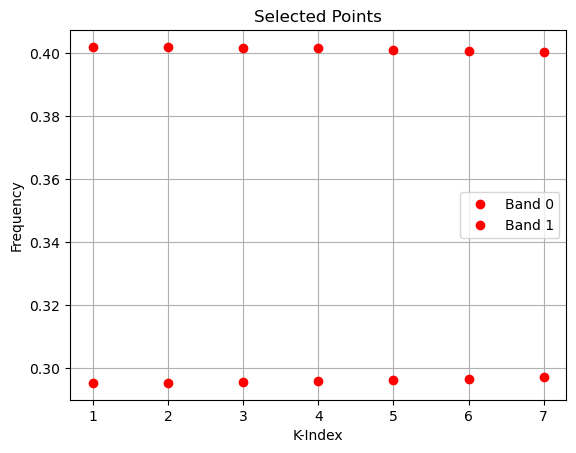

In [19]:
analyzer = FieldAnalyzer(simulation, [2,4], "zodd")
k_indices = analyzer.get_k_indices()
results_df = analyzer.get_eps_mu_impedance_neff("z", "y", average_type = "2D", nonbloch = True, periods = 3, plot=True)


,k_index,band,frequency,eps,mu,impedance,n_eff,kmag
0,1,2,0.295241,0.000000+0.000000j,0.000000+0.000000j,NaN+ NaNj,0.000000+0.000000j,0.000000
1,1,4,0.401916,0.000000+0.000000j,0.000000+0.000000j,NaN+ NaNj,0.000000+0.000000j,0.000000
2,2,2,0.295300,-0.001914+0.000000j,-0.069913+0.000000j,0.165438-0.000000j,-0.011566+0.000000j,0.008333
3,2,4,0.401859,0.011651+0.000000j,0.005315+0.000000j,1.480609+0.000000j,0.007869+0.000000j,0.008333
4,3,2,0.295468,-0.002837+0.000000j,-0.266398+0.000000j,0.103191-0.000000j,-0.027490+0.000000j,0.016667
5,3,4,0.401691,0.045935+0.000000j,0.007634+0.000000j,2.452981+0.000000j,0.018726+0.000000j,0.016667
6,4,2,0.295735,-0.004725+0.000000j,-0.439689+0.000000j,0.103669-0.000000j,-0.045582+0.000000j,0.025000
7,4,4,0.401423,0.100656+0.000000j,0.009616+0.000000j,3.235314+0.000000j,0.031112+0.000000j,0.025000
8,5,2,0.296104,-0.007827+0.000000j,-0.543241+0.000000j,0.120033-0.000000j,-0.065207+0.000000j,0.033333
9,5,4,0.401068,0.172943+0.000000j,0.011515+0.000000j,3.875501+0.000000j,0.044625+0.000000j,0.033333


/zhome/2f/7/202918/miniconda3/envs/nzi-mp/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/zhome/2f/7/202918/miniconda3/envs/nzi-mp/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


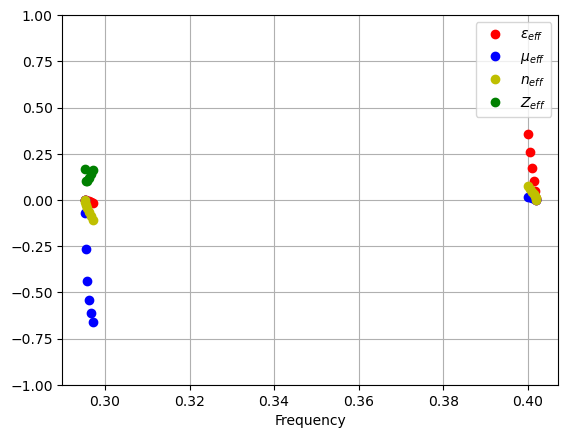

In [21]:

display(results_df)

analyzer.plot_eps_vs_freqs()
analyzer.plot_mu_vs_freqs()
analyzer.plot_neff_vs_freqs()
analyzer.plot_impedance_vs_freqs()
plt.ylim(-1, 1)
plt.show()



In [47]:
display(results_df)

,k_index,band,frequency,eps,mu,impedance,n_eff,kmag
0,1,2,0.266793,0.000000+0.000000j,0.000000+0.000000j,NaN+ NaNj,0.000000-0.000000j,0.000000
1,1,4,0.286717,0.000000+0.000000j,0.000000+0.000000j,NaN+ NaNj,0.000000-0.000000j,0.000000
2,2,2,0.264372,0.296308+0.000000j,0.041368+0.000000j,2.676338+0.000000j,0.110714+0.000000j,0.045455
3,2,4,0.288877,-0.150604+0.000000j,-0.065212+0.000000j,1.519691-0.000000j,0.099101-0.000000j,0.045455
4,3,2,0.258874,0.946474+0.000000j,0.077213+0.000000j,3.501146+0.000000j,0.270333+0.000000j,0.090909
5,3,4,0.293647,-0.484228+0.000000j,-0.110130+0.000000j,2.096874-0.000000j,0.230928-0.000000j,0.090909
6,4,2,0.252157,1.712782+0.000000j,0.125565+0.000000j,3.693315+0.000000j,0.463752+0.000000j,0.136364
7,4,4,0.299183,-0.880328+0.000000j,-0.159317+0.000000j,2.350667-0.000000j,0.374501-0.000000j,0.136364
8,5,2,0.244914,2.498398+0.000000j,0.190063+0.000000j,3.625622+0.000000j,0.689095+0.000000j,0.181818
9,5,4,0.304843,-1.299358+0.000000j,-0.211433+0.000000j,2.479009-0.000000j,0.524144-0.000000j,0.181818


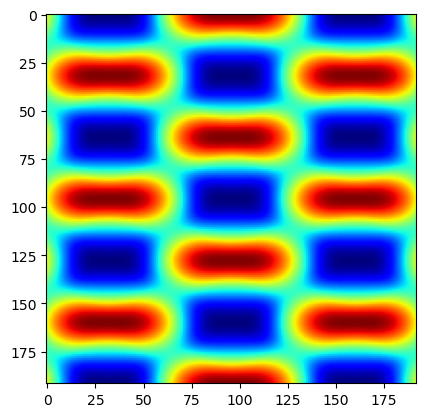

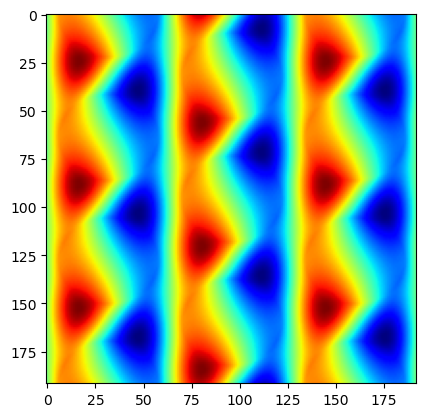

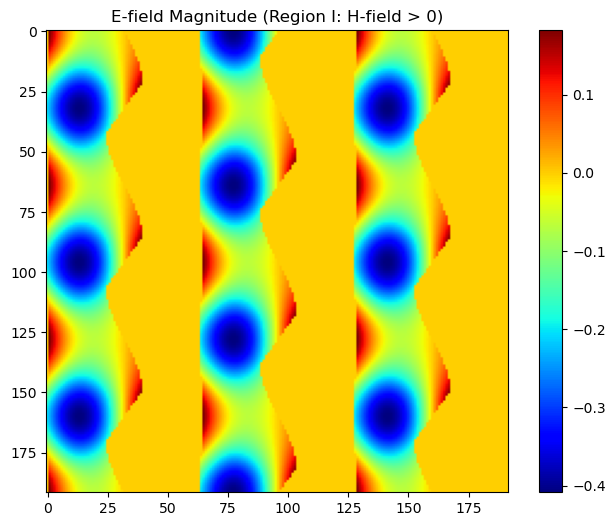

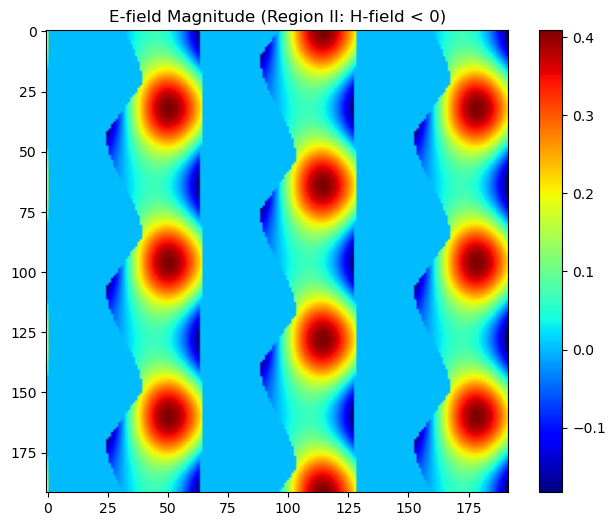

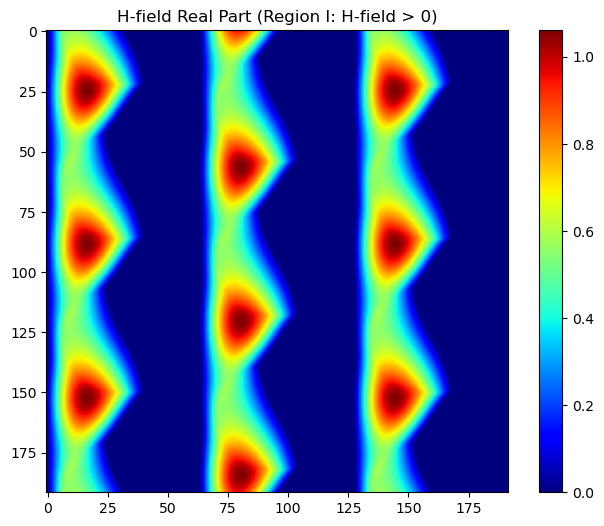

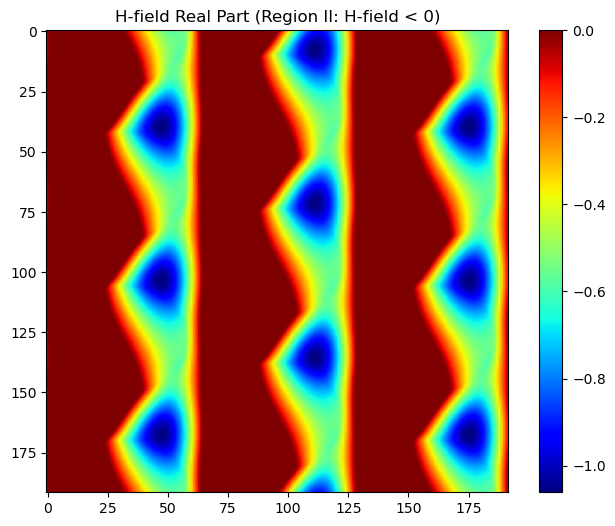

e_i_I: (-0.06676973104576703-0.00823745176103917j)
e_i_II: (0.06676972864204861-0.00814605546605695j)
h_j_I: (0.2428974467897387-0.008191324678610832j)
h_j_II: (-0.24289744403918945-0.008164144977115635j)
E/H I: -0.274888566875573
E/H II: -0.27488856009236506
Epsilon I: -3.6378377295431323
Epsilon II: -3.6378378193111813
Mu I: -0.274888566875573
Mu II: -0.27488856009236506
Epsilon: (-3.637837774427157+0j)
Mu: (-0.274888563483969+0j)
Epsilon: (-4.198785719122724+0j)
Mu: (-0.3408609471952995+0j)
Kmag: 0.265581
Freq: 0.2301


In [20]:
analyzer = FieldAnalyzer(simulation_2D, 1, "tm")

e_field = analyzer.load_efield_data(2, 2, "z")
h_field = analyzer.load_hfield_data(2, 2, "y")
plt.imshow(np.abs(e_field), cmap="jet")
plt.show()
plt.imshow(h_field.real, cmap="jet")
plt.show()

mask_I = analyzer.get_mask(h_field.real, analyzer.field_greater_than_zero)
mask_II = analyzer.get_mask(h_field.real, analyzer.field_less_than_zero)

e_field_masked_I = analyzer.mask_field_data(e_field, mask_I)
e_field_masked_II = analyzer.mask_field_data(e_field, mask_II)

h_field_masked_I = analyzer.mask_field_data(h_field, mask_I)
h_field_masked_II = analyzer.mask_field_data(h_field, mask_II)

plt.figure(figsize=(8, 6))
plt.imshow(e_field_masked_I.real, cmap="jet")
plt.colorbar()
plt.title("E-field Magnitude (Region I: H-field > 0)")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(e_field_masked_II.real, cmap="jet")
plt.colorbar()
plt.title("E-field Magnitude (Region II: H-field < 0)")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(h_field_masked_I.real, cmap="jet")
plt.colorbar()
plt.title("H-field Real Part (Region I: H-field > 0)")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(h_field_masked_II.real, cmap="jet")
plt.colorbar()
plt.title("H-field Real Part (Region II: H-field < 0)")
plt.show()


e_field_avg_2D_I = analyzer.average_2D(e_field_masked_I)
e_field_avg_2D_II = analyzer.average_2D(e_field_masked_II)
h_field_avg_2D_I = analyzer.average_2D(h_field_masked_I)
h_field_avg_2D_II = analyzer.average_2D(h_field_masked_II)
print("e_i_I:", e_field_avg_2D_I)
print("e_i_II:", e_field_avg_2D_II)
print("h_j_I:", h_field_avg_2D_I)
print("h_j_II:", h_field_avg_2D_II)

e_h_I = e_field_avg_2D_I.real / h_field_avg_2D_I.real
e_h_II = e_field_avg_2D_II.real / h_field_avg_2D_II.real
print("E/H I:", e_h_I)
print("E/H II:", e_h_II)
mu_I = e_h_I
mu_II = e_h_II
eps_I = 1/e_h_I
eps_II = 1/e_h_II
print("Epsilon I:", eps_I)
print("Epsilon II:", eps_II)
print("Mu I:", mu_I)
print("Mu II:", mu_II)



eps = np.emath.sqrt(eps_I)*np.emath.sqrt(eps_II)
mu = np.emath.sqrt(mu_I)*np.emath.sqrt(mu_II)
print("Epsilon:", eps)
print("Mu:", mu)


eps, mu = analyzer.get_eps_mu(2, 2, "z", "y", average_type="2D", nonbloch=True, periods=3) 
print("Epsilon:", eps)
print("Mu:", mu) 


kmag, freq = analyzer.get_kmag_freq(2, 2)  
print("Kmag:", kmag)    
print("Freq:", freq) 


In [17]:
df = analyzer.simulation.load_frequency_data("tm")
display(df)
kmag = analyzer.simulation.get_kmag_freq(df, 2, "tm", 2)
print(kmag)

,k index,k1,k2,k3,kmag/2pi,tm band 1,tm band 2,tm band 3,tm band 4,tm band 5,tm band 6,tm band 7,tm band 8
0,1,0.00,0,0,0.000000,0.000000,0.266793,0.286696,0.286717,0.376789,0.376847,0.468681,0.523004
1,2,-0.23,0,0,0.265581,0.077043,0.230100,0.280624,0.312022,0.372091,0.391273,0.461974,0.488075


(0.265581, 0.2301)
